In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import quad

<ipython-input-138-d97b7f75258c>:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'$t_0$']); ax.set_xticks([T0])
<ipython-input-138-d97b7f75258c>:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'$t_0$']); ax.set_xticks([T0])
<ipython-input-138-d97b7f75258c>:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([r'$v_0$']); ax.set_yticks([0.61])


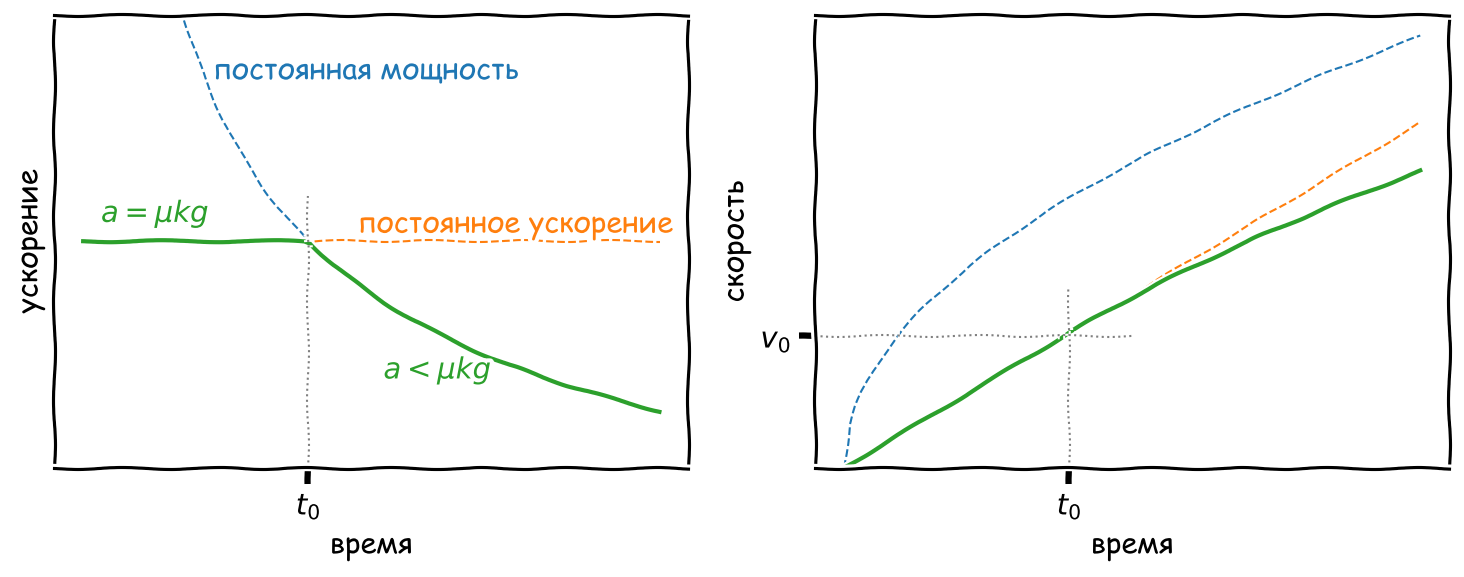

In [138]:
LIMIT = 0.8
T0 = (1 / LIMIT**2) / 2

def accel(t):
  return min(1 / np.sqrt(2 * (t + 1e-10)), LIMIT)

def accel0(t):
  return 1 / np.sqrt(2 * (t + 1e-10))

ts = np.linspace(0, 2, 100)
accels = [accel(t) for t in ts]
accels0 = [accel0(t) for t in ts]
vels = [quad(accel, 0, t)[0] for t in ts]
vels1 = [quad(lambda f: 0.8, 0, t)[0] for t in ts]
vels0 = [quad(accel0, 0, t)[0] for t in ts]

with plt.xkcd():
  fig = plt.figure(figsize=(12, 4), dpi=150)
  ax = plt.subplot(121)
  ax.plot(ts, accels0, lw=1, ls='--')
  ax.plot(ts, [LIMIT] * len(ts), lw=1, ls='--')
  ax.plot(ts, accels)
  ax.axvline(T0, ymax=0.6, c='gray', lw=1, ls=':')
  ax.text(1.5, LIMIT, 'постоянное ускорение', ha='center', va='bottom', c='C1')
  ax.text(0.45, 1.1, 'постоянная мощность', ha='left', va='center', c='C0')
  ax.text(0.25, LIMIT + 0.02, r'$a=\mu k g$', ha='center', va='bottom', c='C2')
  ax.text(1.23, 0.6, r'$a<\mu k g$', ha='center', va='top', c='C2')
  ax.set_ylim(0.4, 1.2)
  ax.set_xticklabels([r'$t_0$']); ax.set_xticks([T0])
  ax.set_yticklabels(''); ax.set_yticks([])
  ax.set_xlabel(r'время')
  ax.set_ylabel(r'ускорение')
  
  ax = plt.subplot(122)
  ax.plot(ts, vels0, lw=1, ls='--')
  ax.plot(ts, vels1, lw=1, ls='--')
  ax.plot(ts, vels)
  ax.axvline(T0, ymax=0.4, c='gray', lw=1, ls=':')
  ax.axhline(.61, xmax=0.5, c='gray', lw=1, ls=':')
  
  ax.set_ylim(0, 2.1)
  ax.set_xticklabels([r'$t_0$']); ax.set_xticks([T0])
  ax.set_yticklabels([r'$v_0$']); ax.set_yticks([0.61])
  ax.set_xlabel(r'время')
  ax.set_ylabel(r'скорость')

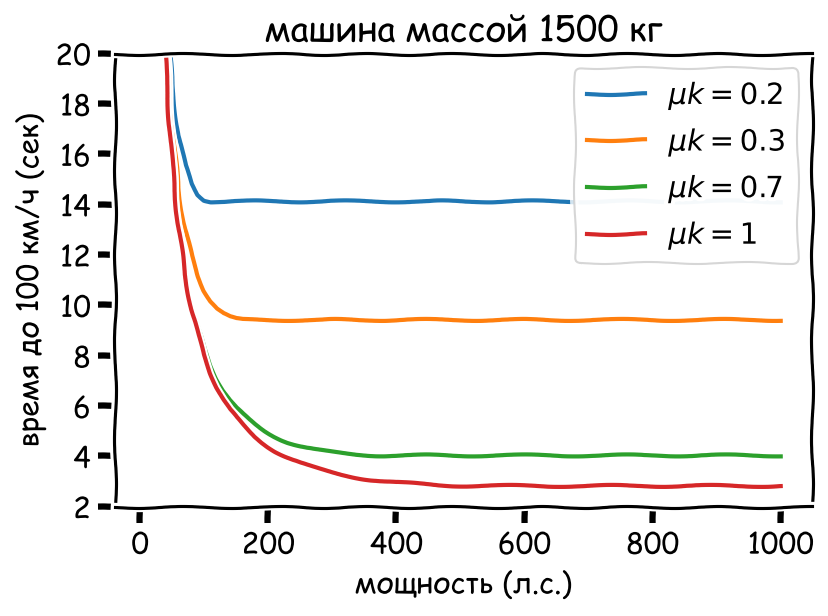

In [144]:
with plt.xkcd():
  fig = plt.figure(figsize=(6, 4), dpi=150)
  ax = plt.subplot(111)
  V = 27.7
  for muk in [0.2, 0.3, 0.7, 1]:
    mukg = 9.8 * muk
    xs = np.linspace(10, 1000, 100)
    povms = xs * (74500 / 100) / 1500
    def time(povm):
      t0 = povm / (mukg**2)
      v0 = mukg * t0
      if (v0 < V):
        return V**2 / (2 * povm) + 0.5 * povm / mukg**2
      else:
        return V / mukg
    ys = [time(povm) for povm in povms]
    ax.plot(xs, ys, label=r'$\mu k={{{}}}$'.format(muk))
  ax.set_ylim(2, 20)
  
  plt.legend()
  ax.set_ylabel(r'время до 100 км/ч (сек)')
  ax.set_xlabel(r'мощность (л.с.)')
  ax.set_title(r'машина массой 1500 кг')

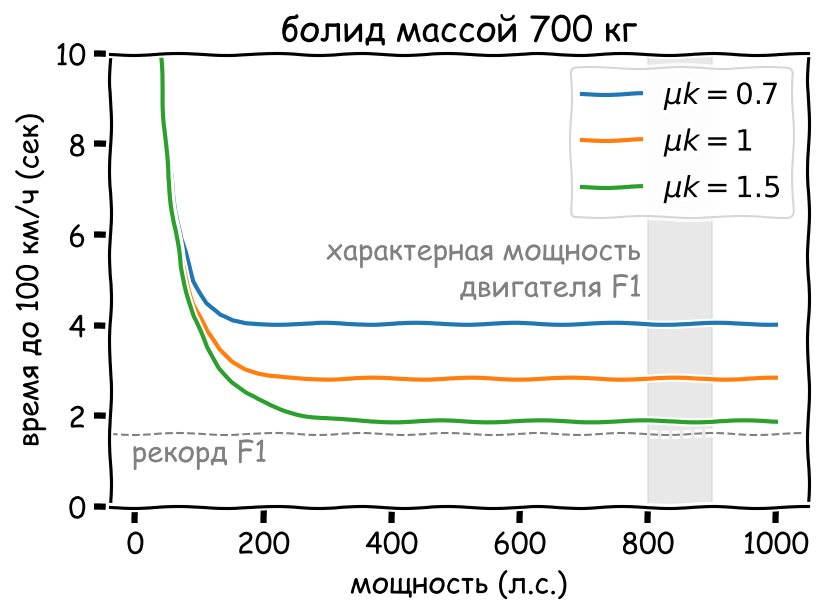

In [149]:
with plt.xkcd():
  fig = plt.figure(figsize=(6, 4), dpi=150)
  ax = plt.subplot(111)
  V = 27.7
  ax.axhline(1.6, c='gray', lw=1, ls='--')
  ax.fill_between([800, 900], 0, 10, color='lightgray', alpha=0.5, transform=ax.get_xaxis_transform())
  ax.text(790, 5.2, 'характерная мощность\nдвигателя F1', va='center', ha='right', c='gray')
  ax.text(100, 1.5, 'рекорд F1', va='top', ha='center', c='gray')
  for muk in [0.7, 1, 1.5]:
    mukg = 9.8 * muk
    xs = np.linspace(10, 1000)
    povms = xs * (74500 / 100) / 700
    def time(povm):
      t0 = povm / (mukg**2)
      v0 = mukg * t0
      if (v0 < V):
        return V**2 / (2 * povm) + 0.5 * povm / mukg**2
      else:
        return V / mukg
    ys = [time(povm) for povm in povms]
    ax.plot(xs, ys, label=r'$\mu k={{{}}}$'.format(muk))
  ax.set_ylim(0, 10)
  plt.legend()
  ax.set_ylabel(r'время до 100 км/ч (сек)')
  ax.set_xlabel(r'мощность (л.с.)')
  ax.set_title(r'болид массой 700 кг')

In [209]:
-np.sqrt(2 * Poverm * t0) + v0

-6.997485350747297

In [222]:
quad(vel, 0, 10.6)

(158.89356150854312, 3.024725456606229e-07)

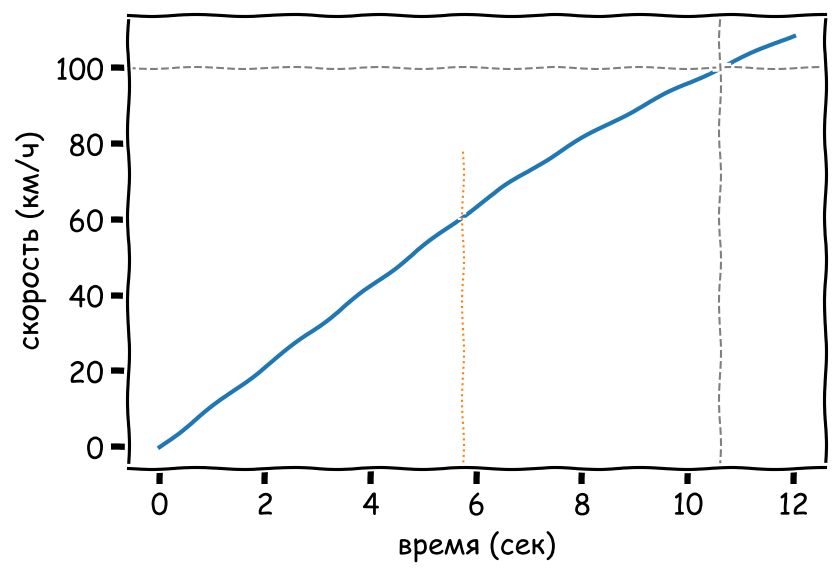

In [221]:
mu = 0.3
g = 9.8
Poverm = 74500 / 1500
V = 27.7

t0 = Poverm / ((mu * g)**2)
v0 = mu * g * t0

def vel(t):
  if t < t0:
    return mu * g * t
  else:
    return np.sqrt(2 * Poverm * (t - t0) + v0**2)
  
ts = np.linspace(0, 12, 100)
vels = [vel(t) for t in ts]
# vels = [quad(accel, 0, t)[0] for t in ts]

with plt.xkcd():
  fig = plt.figure(figsize=(6, 4), dpi=150)
  ax = plt.subplot(111)
  ax.plot(ts, np.array(vels) * 100 / V)
  ax.axhline(100, c='gray', lw=1, ls='--')
  ax.axvline(10.6, c='gray', lw=1, ls='--')
  ax.axvline(t0, c='C1', lw=1, ls=':', ymax=0.7)
#   ax.plot(ts, [LIMIT] * len(ts), lw=1, ls='--')
#   ax.plot(ts, accels)
#   ax.axvline(T0, ymax=0.6, c='gray', lw=1, ls=':')
#   ax.text(1.5, LIMIT, 'постоянное ускорение', ha='center', va='bottom', c='C1')
#   ax.text(0.45, 1.1, 'постоянная мощность', ha='left', va='center', c='C0')
#   ax.text(0.25, LIMIT + 0.02, r'$a=\mu k g$', ha='center', va='bottom', c='C2')
#   ax.text(1.23, 0.6, r'$a<\mu k g$', ha='center', va='top', c='C2')
#   ax.set_ylim(0.4, 1.2)
#   ax.set_xticklabels([r'$t_0$']); ax.set_xticks([T0])
#   ax.set_yticklabels(''); ax.set_yticks([])
  ax.set_xlabel(r'время (сек)')
  ax.set_ylabel(r'скорость (км/ч)')
  
#   ax = plt.subplot(122)
#   ax.plot(ts, vels0, lw=1, ls='--')
#   ax.plot(ts, vels1, lw=1, ls='--')
#   ax.plot(ts, vels)
#   ax.axvline(T0, ymax=0.4, c='gray', lw=1, ls=':')
  
#   ax.set_ylim(0, 2.1)
#   ax.set_xticklabels([r'$t_0$']); ax.set_xticks([T0])
#   ax.set_yticklabels(''); ax.set_yticks([])
#   ax.set_xlabel(r'время')
#   ax.set_ylabel(r'скорость')